# Neural Networks Assignment, 2025 A2 <ignore>
## Overview
The overarching goal of this assignment is to demonstrate your understanding of the use of Neural Networks (NNs) to solve regression and classification tasks. You will be asked to carry out two tasks, each of which will contain subtasks requiring a mixture of short and long responses from you. There are 163 marks available in total. This will be converted into a percentage.

## Instructions
### Code and Markdown cells
All of your report, including code and Markdown/text, ***must*** be written up in ***this*** notebook. Please make sure you change the title of this file so that XXXXXX is replaced by your candidate number. You can use code cells, where provided, to write code to implement, train, test, and analyse your NNs, as well as to generate figures to plot data and the results of your experiments. If you wish to add more code cells, you may do so immediately after the code cells that have been provided, but do not add any code cells anywhere else in this file. You must use the Markdown/text cells that are provided for verbose responses to the subtasks, and have "*Replace this text with...*" in italics, replacing that text with your own text. So that we can mark your reports with greater consistency, please ***do not***:

* add any of your own Markdown cells.
* rearrange the sequence of cells in this notebook.
* delete any cells, including the ones explaining what you need to do.

### Plotting figures
All plots of data ***must*** be produced as output from a code cell. Any plots that have been imported as images, rather than being the output of a plot function (such as that provided by matplotlib) will not receive marks. This is to ensure that you did the work to produce that plot. Diagrams, e.g. of your network architecture, can be imported as images. Any plots should have an accompanying caption that states the Figure number and a detailed description of what the figure shows (see the guidenace in the file ```useful_code_for_figures_equations.ipynb```). 

### Writing code
Please provide verbose comments throughout your code so that it is easy for us to interpret what you are attempting to achieve. Long comments are useful at the beginning of a block of code. Short comments, e.g. to explain the purpose of a new variable, or one of several steps in some analyses, are useful on every few lines of code, if not on every line. Please do not use the code cells for writing verbose responses to subtasks, which should instead be written in the provided Markdown cells.

# TASK 1 - 93 marks available <ignore>

## Subtask 1A - 5 marks <ignore>
Using Pytorch, create a class that defines a multi-layer perceptron (MLP). The MLP must:
* take inputs that are either 1-dimensional or 2-dimensional
* have three hidden layers with 16 neurons in each layer, and a 1-dimensional output
* use ReLU non-linear activations for the hidden layers, and no nonlinearity for the output layer. 

The class must include a forward pass function that takes an input, X, and returns an output, Y, where X is a MxN tensor (M samples, N input dimensions), and Y is a Mx1 tensor such that each sample produces a scalar output.

Use the code cell below to create your model. For each line of code, write a short comment to explain what the code does.

In [1]:
import torch
import torch.nn as nn

# Define a multi-layer perceptron class using PyTorch's nn.Module
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        
        # Define the network architecture
        self.model = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.model(x)

## Subtask 1B - 3 marks <ignore>
Provide three reasons why the ReLU nonlinearity might be a better choice than a Sigmoid nonlinearity for a regression task.

1. Avoids vanishing gradients, which means ReLU doesn't saturate large input values. This means gradient can remain significant during the backpropagation. Thus, during the training the weights will update supporting the training.
2. ReLU is a lot faster to compute than sigmoid, This is due to the requirements being a lot simpler (Threshold operation (max(0,x)) instead of exponentials). This means there will be an observable increase in training times and performance.
3. For negative inputs ReLU will output zero which will lead to more efficient learning does to sparsity in the network.

## Subtask 1C - 2 marks <ignore>
Data for Task 1 is to be generate using the following equation:
$$
y_i = 0.2\left(x_i - 3\right)^2 + 0.2\xi_i
$$
where <lt>$i$ denotes the sample and <lt>$\xi$ is a random variable drawn from a normal distribution with zero mean and unit variance. What is a suitable loss function to perform regression on pairs of (x,y) samples generated by this function? Why? 

For this equation the most suitable loss function is mean squared error loss. This is due to MSE measuring the difference between predicted outputs and true outputs. This means that its ideal for tasks involving regression, like in the equation above. $$y_i$$ Since the errors are being squared the large deviation are penalized which means the modal is pushed to make more accurate prediction.


## Subtask 1D - 8 marks <ignore>
Name two gradient descent optimisers that were discussed in the lectures, and that might be used for this regression task. Describe an advantage and a disadvantage for using each, providing reasons.

The first gradient descent optimiser that might be used for this regression task could be stochastic gradient descent. An advantage to using SGD for this regression task would be efficient when dealing with large datasets. This is due to update weights using only a subset for each of the steps. This would allow for faster iterations while also adding noise, thus potentially helping escape local minima. Unfortunately, convergence can be slow and noisy and a increase of complex loss surfaces since it's sensitive to gradient noise.
The second gradient descent optimiser that might be used for this regression task could be Adaptive Moment Estimation. Adam is efficient and effective in practice. This is due to the momentum and adaptive learning rates. One disadvantage over SGD is that in some cases there can be an poorer generalisation when dealing with simple or small datasets. 

## Subtask 1E - 6 marks <ignore>
What is meant by the term "batch" when training a NN? What is the smallest and the largest possible batch sizes? What are the advantages of using small batch sizes? What are the advantages of using large batch sizes?

Within neural network training, the term "batch" relates to the training data that is processed through the network. This would relate to the single forward and backward pass prior to updates to the model parameters. Batches allows for efficiency and increase speed when training. The advantages of batching on small datasets(1) can show to have faster iteration on each update and utilised low memory. It also would create more noise into the gradient estimate, which may lead to a better generalisation. The advantage to using batch on large datasets (Training entire datasets) would provide smoother convergence due to the stable gradient estimates. If there is sufficient computation resource available and there is correct implementation of paralysation, it can lead to a fast overall convergence.

## Subtask 1F - 16 marks <ignore>
Using the model you built in 1A, and data generated by the code below, demonstrate how the size of the training dataset affects the amount of overfitting when the input data is 1-dimensional. Your evidence should come in the form of learning curves that show the loss as the dependent variable and training progress as the independent variable. These learning curves should appear similar to the ones you were shown in the lectures. You must use at least 5 different training dataset sizes to demonstrate the transition from strong overfitting to intermediate overfitting to no overfitting. For each dataset size, rerun the model using a different random seed at least 5 times. The learning curves you plot must show the mean loss, when averaged across reruns. The output of your code cell must include these figures, and the figures must be generated by code that is executed in the cell. You must not save figures and then import them. 

**Note**: you may have to experiment with various different dataset sizes before you select the 5 or more sizes that effectively demonstrate strong, intermediate, and no overfitting. Choose these training dataset sizes wisely, as you will be required to compare results to a new scenario in subtask 1H.

In [2]:
import torch

###
### Use this code to generate the data
###

# Funtion definition
def func(x,ndims):
    y = 0. # initialise y
    for i in range(ndims): # for each input dimension
        y += (0.2 * (x[:,i] - 3.0)) ** 2 # increment y value
    y += torch.randn(y.size()) * 0.2 # add normally distributed noise
    return y

# Define parameters and generate data
######################################################################
######################################################################
# PROVIDE VALUES FOR THESE VARIABLES ONLY. 
# LEAVE ALL OTHER VARIABLES UNTOUCHED
ndims = 1
Ntrain = 100
Nbatch = 32
######################################################################
######################################################################
Ntest = 500
x_train = torch.rand(Ntrain, ndims)*10.0  # Inputs from 0 to 10
y_train = func(x_train, ndims) # generate noisey y training data
y_train = y_train.view(-1, 1) # reshape y data

x_test = torch.rand(Ntest, ndims)*10.0  # Inputs from 0 to 10
y_test = func(x_test, ndims) # generate noisey y test data
y_test = y_test.view(-1, 1) # reshape y data

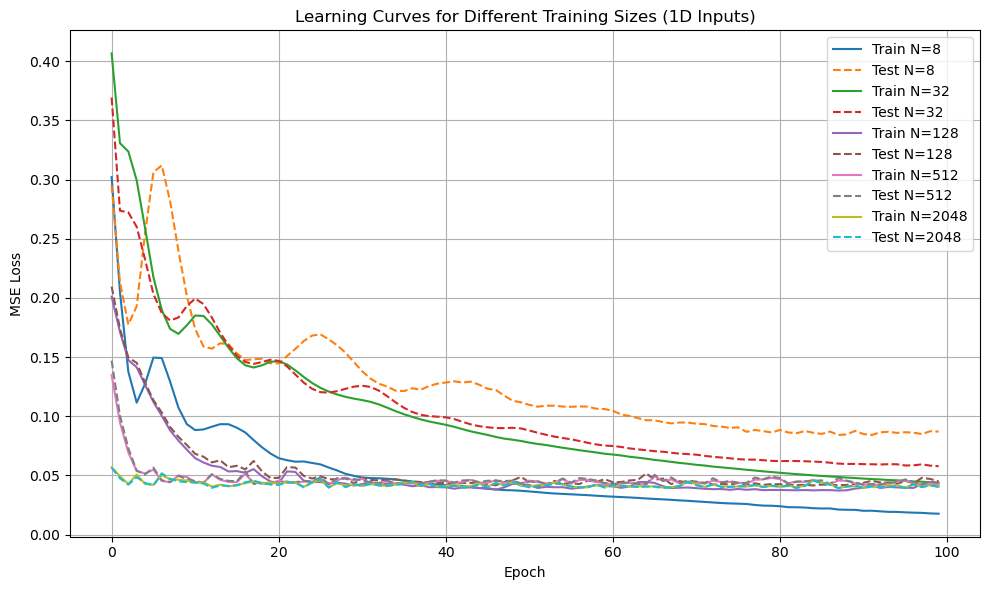

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Train and evaluate function
def train_model(Ntrain, seed, epochs=100, batch_size=32):
    torch.manual_seed(seed)
    
    x_train = torch.rand(Ntrain, 1) * 10.0
    y_train = func(x_train, 1).view(-1, 1)
    x_test = torch.rand(500, 1) * 10.0
    y_test = func(x_test, 1).view(-1, 1)

    model = MLP(1)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(x_train.size(0))
        for i in range(0, x_train.size(0), batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = x_train[indices], y_train[indices]

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        # Record training loss
        model.eval()
        with torch.no_grad():
            train_pred = model(x_train)
            test_pred = model(x_test)
            train_loss = criterion(train_pred, y_train).item()
            test_loss = criterion(test_pred, y_test).item()
            train_losses.append(train_loss)
            test_losses.append(test_loss)

    return train_losses, test_losses

# Experiment with different training sizes
train_sizes = [8, 32, 128, 512, 2048]
results = {}

for size in train_sizes:
    all_train = []
    all_test = []
    for seed in range(5):
        tr_loss, te_loss = train_model(size, seed)
        all_train.append(tr_loss)
        all_test.append(te_loss)
    
    results[size] = {
        "train": np.mean(all_train, axis=0),
        "test": np.mean(all_test, axis=0)
    }

# Plot the learning curves
plt.figure(figsize=(10, 6))
for size in train_sizes:
    plt.plot(results[size]["train"], label=f"Train N={size}")
    plt.plot(results[size]["test"], '--', label=f"Test N={size}")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curves for Different Training Sizes (1D Inputs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Subtask 1G - 5 marks <ignore>
Describe the results you present in 1F. In your description, include a statement of the smallest training dataset size at which overfitting is no longer seen. Also include an explanation about why you might expect there to be a gap between the training and test losses, even if the model is not overfitting.

As we can see, the results to subtask 1f shows the effects of different dataset sizes have on overfitting when training. We observe a strong overfitting for the smallest dataset size due to the model having a low training loss. We can also see poor performs on unseen data. You can also see a large amount of fluctuations in the graph, which indicates a poor ability to generalise.
When we start to increase the data set size (N = 128) the overfitting which was observed on the smallest dataset reduces. Although this observation is seen, the gap between the training and test loss is still present. With the larger dataset size (N = 512) the curve of the training and test loss start to come together and the largest dataset (N = 2048) It's pretty difficult to see the difference.

Thus, when observing and identifying which of the datasets is the smallest, where we can no longer see overfitting. This is seen at the earliest around n = 512. Although a dataset of around n = 512 has minimal overfitting, there is still an observable gap between training and test loss. 

## Subtask 1H - 13 marks <ignore>
Repeat subtask 1F, but for 2-dimensional inputs. Make sure that you use suitable dataset training sizes to demonstrate the transition from strong overfitting to intermediate overfitting to no overfitting. You must include the smallest dataset size at which no overfitting is seen in subtask 1F. Remember, you must produce figures, just as you did for subtask 1F.

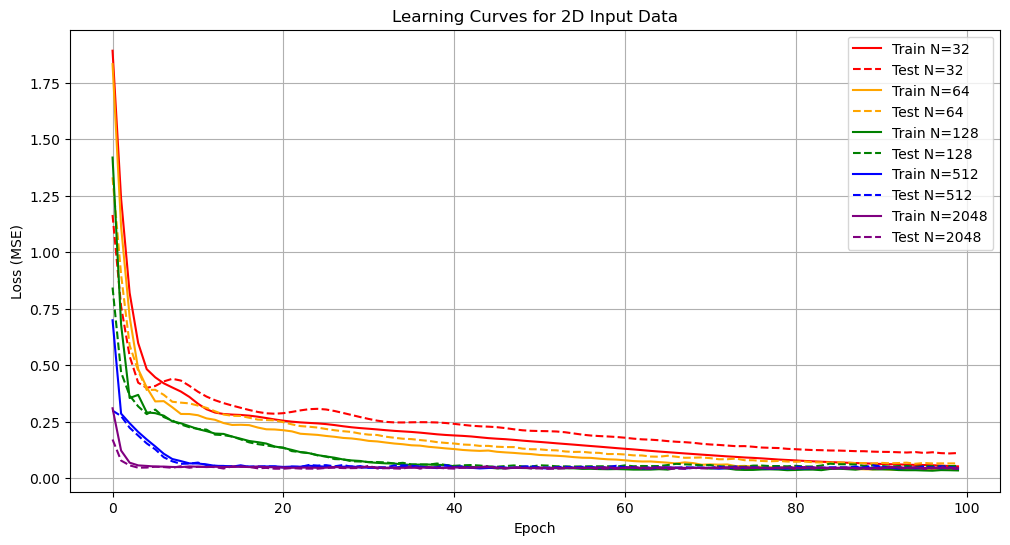

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Training function
def train_and_evaluate(ndims, Ntrain, Ntest, Nbatch, epochs=100, runs=5):
    train_losses = []
    test_losses = []

    for run in range(runs):
        torch.manual_seed(run)

        # Generate data
        x_train = torch.rand(Ntrain, ndims) * 10.0
        y_train = func(x_train, ndims).view(-1, 1)
        x_test = torch.rand(Ntest, ndims) * 10.0
        y_test = func(x_test, ndims).view(-1, 1)

        model = MLP(ndims)
        optimizer = optim.Adam(model.parameters(), lr=0.01)
        criterion = nn.MSELoss()

        train_loss_history = []
        test_loss_history = []

        for epoch in range(epochs):
            # Shuffle and batch training data
            perm = torch.randperm(Ntrain)
            model.train()
            batch_losses = []
            for i in range(0, Ntrain, Nbatch):
                idx = perm[i:i + Nbatch]
                xb, yb = x_train[idx], y_train[idx]

                optimizer.zero_grad()
                y_pred = model(xb)
                loss = criterion(y_pred, yb)
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.item())

            train_loss_history.append(sum(batch_losses) / len(batch_losses))

            model.eval()
            with torch.no_grad():
                test_pred = model(x_test)
                test_loss = criterion(test_pred, y_test)
                test_loss_history.append(test_loss.item())

        train_losses.append(train_loss_history)
        test_losses.append(test_loss_history)

    mean_train_loss = torch.tensor(train_losses).mean(dim=0)
    mean_test_loss = torch.tensor(test_losses).mean(dim=0)

    return mean_train_loss, mean_test_loss

# Plotting results for different dataset sizes
dataset_sizes = [32, 64, 128, 512, 2048]
colors = ['r', 'orange', 'g', 'b', 'purple']
Ntest = 500
Nbatch = 32

plt.figure(figsize=(12, 6))
for Ntrain, color in zip(dataset_sizes, colors):
    train_loss, test_loss = train_and_evaluate(ndims=2, Ntrain=Ntrain, Ntest=Ntest, Nbatch=Nbatch)
    plt.plot(train_loss, label=f'Train N={Ntrain}', color=color, linestyle='-')
    plt.plot(test_loss, label=f'Test N={Ntrain}', color=color, linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Learning Curves for 2D Input Data')
plt.legend()
plt.grid(True)
plt.show()


## Subtask 1I - 6 marks <ignore>
Explain how increasing the dimensionality of the inputs affects the degree of overfitting by the model. Give reasons. Backup your statements by explicitly referring to specific plots in the figures you presented above. In you explanation, state whether there is an increase / a decrease / no change in the smallest dataset size that produces no overfitting, when gong from 1-dimensional inputs to 2-dimensional inputs. 

As the dimensionality of the input changes from 1D to 2D, the model increased in complexity. Thus, to achieve the same level of generalisation it required a larger training model. For example, when observing the point in which overfitting wasn't present in the 1D model the dataset was around 512 but in the 2D model the point of disappearance for overfitting was around 128.

This meant that since the were more dimensions on, the model was able to fit more complex pattern and parameter in the data. Thus leading to the models learning to overfit the training set and progressing to gap developing between the train and test performance.

This can be evident when comparing the graph created of subtask 1F and 1H. Se can see the gap between training and test loss is larger for the 2D case when the data set is small and closes slower. Thus when moving from 1D to 2D inputs the point in which overfitting is seen increases.

## Subtask 1J - 7 marks <ignore>
Dropout is one form of regularisation that can help to mitigate against overfitting. Explain how dropout is implemented, and how it acts as a regulariser. Explain what additional steps must be taken to ensure that the loss for training data can be fairly compared to the loss for test data? Name another method that helps to prevent overfitting, and any precautions that must be taken when using that method.

Dropout is a technique where, during training, neurons in a layer are randomly set to zero at each forward pass. This is done to prevent too much reliance on any specific neuron and pushed the network to learn different representations. This behaviour also leads the model to become more robust and better equipped to deal with unseen data.

When it comes to testing, dropout is turn-off so that the entirety of the network is utilised. This is done to ensure a level consistently between training and testing magnitudes. 

To ensure the losses are fairly compared when training and testing, the dropout must be disabled. This has to set during the evaluation stage since it would interfere with the results. This is due to the addition of artificial randomness.

## Subtask 1K - 16 marks <ignore>
Replicate the model used in subtask 1A in the code cell below, adding dropout after each of the two hidden layers. Using the 2-dimensional input data, and a training dataset size that produced overfitting, investigate how the dropout probability affects overfitting and generalisability of the model. You must use at least 5 different dropout probabilities to demonstrate the transition from strong overfitting to intermediate overfitting to no overfitting. For each dropout probability, rerun the model using a different random seed at least 5 times. The learning curves you plot must show the mean loss, when averaged across reruns. The output of your code cell must include these figures, and the figures must be generated by code that is executed in the cell. You must not save figures and then import them. 

**Note**: you may have to experiment with various dropout probabilities before you select the 5 or more probabilities that effectively demonstrate strong, intermediate, and no overfitting.

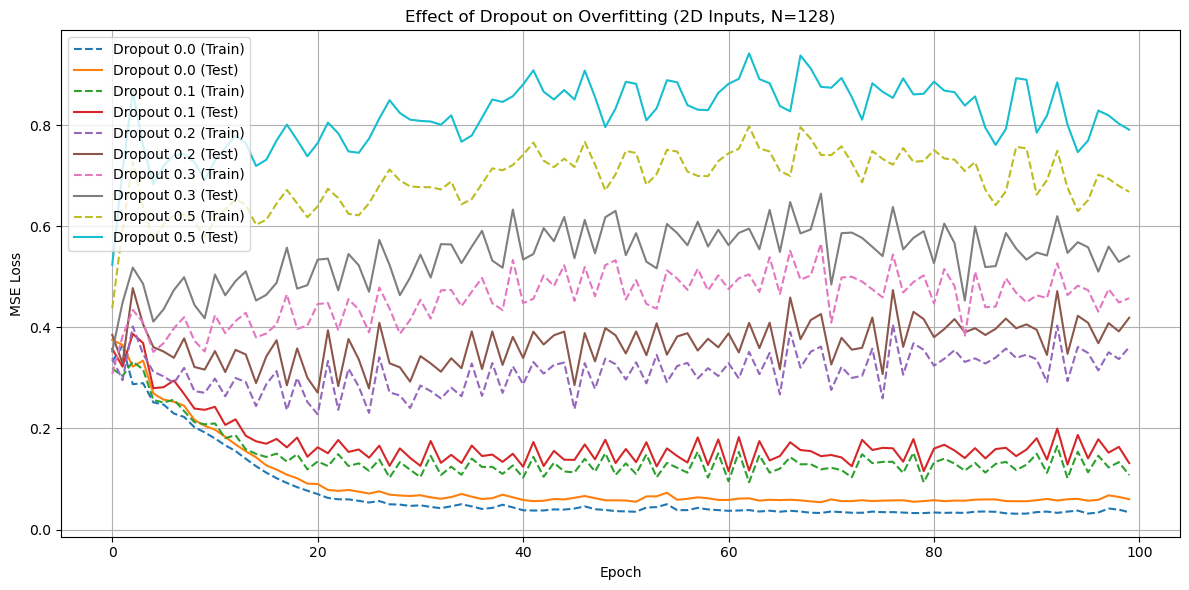

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Define MLP with Dropout
class MLPWithDropout(nn.Module):
    def __init__(self, input_dim=2, dropout_p=0.0):
        super(MLPWithDropout, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

# Parameters
ndims = 2
Ntest = 500
Ntrain = 128  # a size that causes overfitting
Nbatch = 32
epochs = 100
num_seeds = 5
dropout_probs = [0.0, 0.1, 0.2, 0.3, 0.5]

# Data generation (same for all runs)
torch.manual_seed(0)
x_train = torch.rand(Ntrain, ndims) * 10.0
y_train = func(x_train, ndims).view(-1, 1)
x_test = torch.rand(Ntest, ndims) * 10.0
y_test = func(x_test, ndims).view(-1, 1)

# Results containers
train_loss_results = {}
test_loss_results = {}

# Experiment loop
for p in dropout_probs:
    train_losses = []
    test_losses = []

    for seed in range(num_seeds):
        torch.manual_seed(seed)
        model = MLPWithDropout(input_dim=2, dropout_p=p)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        criterion = nn.MSELoss()

        epoch_train_losses = []
        epoch_test_losses = []

        for epoch in range(epochs):
            model.train()
            permutation = torch.randperm(x_train.size(0))

            for i in range(0, x_train.size(0), Nbatch):
                indices = permutation[i:i+Nbatch]
                batch_x, batch_y = x_train[indices], y_train[indices]

                optimizer.zero_grad()
                y_pred = model(batch_x)
                loss = criterion(y_pred, batch_y)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                train_pred = model(x_train)
                test_pred = model(x_test)
                epoch_train_losses.append(criterion(train_pred, y_train).item())
                epoch_test_losses.append(criterion(test_pred, y_test).item())

        train_losses.append(epoch_train_losses)
        test_losses.append(epoch_test_losses)

    train_loss_results[p] = np.mean(train_losses, axis=0)
    test_loss_results[p] = np.mean(test_losses, axis=0)

# Plotting
plt.figure(figsize=(12, 6))
for p in dropout_probs:
    plt.plot(train_loss_results[p], label=f"Dropout {p} (Train)", linestyle='--')
    plt.plot(test_loss_results[p], label=f"Dropout {p} (Test)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Dropout on Overfitting (2D Inputs, N=128)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Subtask 1L - 6 marks <ignore>
Explain how increasing the dropout probability affects overfitting. Describe any other effects you observe as a consequence of using dropout, and suggest reasons as to why they occur.

We can see when the probability of dropout increase, the model's overall robustness increase, relating to overfitting. Because of the effect dropout has with randomly deactivating subsets of neurons when training, this would stop the model from developing a heavy bias on certain paths through the network. This is due to the model having to be forced to learn generalised patterns, which further develops the performance on unseen data.

If we look at the results in subtask 1K at a dropout of 0.0 we observe an overfitting patter where the training is low, but the test loss is much higher in relation. When that dropout increase to 0.1 or 0.2 the gap between the training and test loss begins to decrease, showing the model increases generalisation performance. Finally, we can observe that once the dropout breaks 0.3 the gap increases again, indicating that too much dropout can impact the performance of learning in a negative light. 

In conclusion, an average dropout has shown to improve the generalisation through reducing the overfitting but once that dropout increase the performance decreasing due to the limits in the model's capacity.

# Task 2 - 70 marks available<ignore>
You will be asked to replicate, as closely as possible, the convolutional neural network (CNN) proposed in the seminal paper by LeCunn et al. in 1989, and apply it to an image classification task using the MNIST dataset. A PDF copy of the paper is provided in the assessment zip-file (called 1989.lecunn.jackel.pdf). 

## Subtask 2A - 19 marks<ignore>
Read the methodological sections of the paper, that is, sections 3 and 4 (subheadings "Network Design" and "Experimental Environment"). Some of the terminology we have used in the lectures had not yet become standard at the time this paper was written. Moreover, some of their techniques are no longer standard practice. Nevertheless, the descriptions should make it possible to understand how the model has been built and trained. Answer the following questions (1 mark per question, and 4 marks for Question 10). Write your answers in the markdown cell below (these answers will not contribute to your word count).

1) What are the dimensions of the input images? 
2) How are the input images preprocessed? 
3) How many convolutional layers are there?
4) How many fully connected layers are there?
5) What are the dimensions of the filters used in the first convolutional layer (height x width x depth)? 
6) What are the dimensions of the filters used in the second convolutional layer (height x width x depth)? 
7) How many filters are used for each of the convolutional layers? 
8) What stride is used for each convolutional layer? 
9) What is the padding size used for each convolutional layer? 
10) For each layer, what are the lower and upper limits of weights? 
11) How many units (neurons) are in the fully connected hidden layer? 
12) How many output units are there? 
13) Which two nonlinearities are used in the model? 
14) What loss function is used? 
15) What type of optimisation is used? 
16) What is the batch size? 

*Provide your answers in this cell. They will not contribute to your word count.* <ignore>

1) 
2) 
3) 
4) 
5) 
6) 
7) 
8) 
9) 
10) 
    * Layer 1:
    * Layer 2:
    * Layer 3:
    * Output Layer:
11) 
12) 
13) 
14) 
15) 
16) 


## Subtask 2B - 4 marks<ignore>

For each convolutional layer in their paper, state whether or not the filters correctly tile the inputs to each layer. Use the equation to determine the dimensions of the activation maps to explain your answer.

*Replace this text with your response*

## Subtask 2C - 2 marks<ignore>

How does the application of filters in the second convolutional layer differ to what has been taught in the lectures (and is standard practice in modern usage)?

*Replace this text with your response*

## Subtask 2D - 3 marks<ignore>

Suggest a nonlinear activation function for the hidden layers that may improve the performance of the model. Give two reasons for the expected improvement.

*Replace this text with your response*

## Subtask 2E - 2 marks<ignore>

What characteristics of the nonlinearity in the output will slow down learning?

*Replace this text with your response*

## Subtask 2F - 3 marks<ignore>

Suggest a different loss function that may improve the performance of the model. Give two reasons for the expected improvement.

*Replace this text with your response*

## Subtask 2G - 19 marks<ignore>

Using the hyperparameters extracted from the paper in subtask 2A, replicate their CNN in the code cell below. You may use the modern, standard application of filters, so do not have to guess their exact implementation for the second layer. Moreover:

* replace the nonlinearities with the alternative you proposed in subtask 2D.
* replace the loss function with the alternative you proposed in 2F.
* use appropriate weight initialisation for the nonlinearity you are using (this can be achieved using PyTorch's torch.nn.init functionality). 
* if you think it would be beneficial to use a different batch size to the one used in the paper, do so, otherwise, keep it the same.

**Note**: if you download the MNIST dataset from PyTorch, the images are 28 x 28, and will need to be downsampled to 16 x 16. Be sure to provide good comments, e.g. short comments to explain what each line of code is doing, and comment blocks to explain what each section of code is doing.

Plot figures to show the model's performance as an error rate (the percentage of samples incorrectly classified) for both the training and test data, as a function of training progress. 

In [6]:
###
### Add your code to complete Subtask 2F here
###

## Subtask 2H - 4 marks<ignore>

Comment on how your version of the model compares to the model in the paper, in terms of the models' error rates on the training and test data.

*Replace this text with your response*

## Subtask 2I - 10 marks<ignore>

Using the code cell below, demonstrate the robustness of your model (it's ability to maintain its performance) to input translations. Ensure that you show how robustness varies as a function of translation distance. Produce a figure to visualise your findings.

In [7]:
###
### Add your code to complete Subtask 2I here
###

## Subtask 2J - 4 marks<ignore>

Describe how you would expect your results in Subtask 2I to change if, instead of using the filter stride to downsample at each convolutional layer, you instead used average pooling. What if you used max pooling instead of average pooling? Provide reasons for your answers.

*Replace this text with your response*